# Chapter 3 — Introduction to Neural Prediction: Forward Propagation

**Grokking Deep Learning — Andrew W. Trask**

> **Focus:** bagaimana sebuah neural network melakukan **prediction** dari input menggunakan **weights**.

### Learning Objectives
- memahami hubungan **Input → Weight → Prediction**;
- memahami **weighted sum** dan **dot product**;
- memahami **multiple inputs** dan **multiple outputs**;
- memahami **vector, matrix, vector-matrix multiplication**;
- memahami konsep **predicting on predictions**.

## 1. Step 1 — Predict

Chapter 2 memperkenalkan:

**PREDICT → COMPARE → LEARN**

Chapter 3 fokus pada **PREDICT**.

```text
┌────────────┐      ┌─────────────────┐      ┌────────────┐
│ Input Data │ ───► │ Neural Network  │ ───► │ Prediction │
└────────────┘      │    + Weights    │      └────────────┘
                    └─────────────────┘
```

Buku memulai dari network yang sangat sederhana: **satu input → satu prediction**.

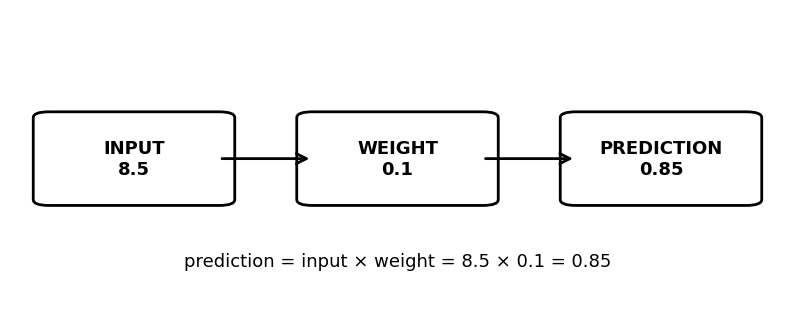

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(10, 3.8))

boxes = [
    (0.05, 0.35, 0.22, 0.28, "INPUT\n8.5"),
    (0.39, 0.35, 0.22, 0.28, "WEIGHT\n0.1"),
    (0.73, 0.35, 0.22, 0.28, "PREDICTION\n0.85")
]

for x, y, w, h, text in boxes:
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle="round,pad=0.02",
                                fill=False, linewidth=2))
    ax.text(x+w/2, y+h/2, text, ha="center", va="center",
            fontsize=13, weight="bold")

for x1, x2 in [(0.27,0.39),(0.61,0.73)]:
    ax.add_patch(FancyArrowPatch((x1,0.49),(x2,0.49),
                                 arrowstyle="->", mutation_scale=18,
                                 linewidth=2))

ax.text(0.5, 0.12, "prediction = input × weight = 8.5 × 0.1 = 0.85",
        ha="center", fontsize=13)
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis("off")
plt.show()

**Interpretasi:** weight bekerja seperti *volume knob*. Nilainya menentukan seberapa kuat input memengaruhi prediction.

## 2. The Simplest Neural Network

Model pertama pada chapter:

**prediction = input × weight**

Dengan data:

| Input | Weight | Prediction |
|---:|---:|---:|
| 8.5 | 0.1 | 0.85 |

Tidak ada proses learning di sini. Network hanya melakukan **forward prediction** menggunakan weight yang tersedia.

In [2]:
weight = 0.1

def neural_network(input, weight):
    prediction = input * weight
    return prediction

number_of_toes = [8.5, 9.5, 10, 9]
input = number_of_toes[0]

pred = neural_network(input, weight)
print("Prediction:", pred)

Prediction: 0.8500000000000001


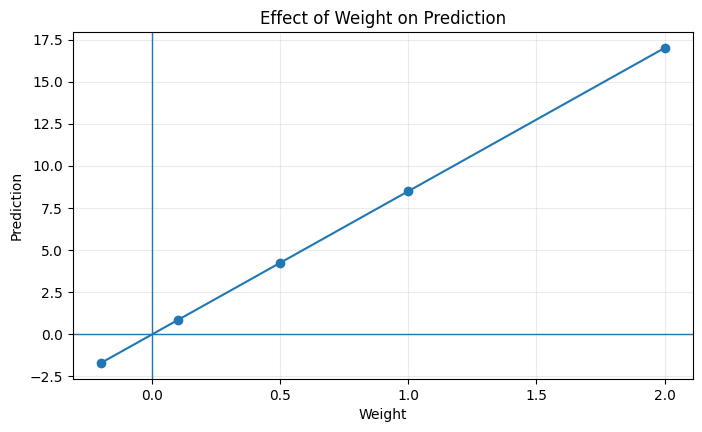

In [3]:
import matplotlib.pyplot as plt

weights = [-0.2, 0.1, 0.5, 1.0, 2.0]
input_value = 8.5
predictions = [input_value * w for w in weights]

plt.figure(figsize=(8, 4.5))
plt.plot(weights, predictions, marker="o")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("Weight")
plt.ylabel("Prediction")
plt.title("Effect of Weight on Prediction")
plt.grid(alpha=0.25)
plt.show()

### Apa yang ditunjukkan chart?

Semakin besar **weight**, semakin besar prediction untuk input yang sama.

- weight negatif → prediction negatif;
- weight mendekati 0 → prediction kecil;
- weight besar → input diperkuat.

Ini membantu melihat mengapa buku menyebut weight sebagai **volume knob**.

## 3. Multiple Inputs → Weighted Sum

Satu input sering tidak cukup. Chapter kemudian menggunakan tiga informasi:

- `toes`
- `wlrec`
- `nfans`

Setiap input memiliki weight sendiri.

```text
toes  ──× w₁ ──┐
wlrec ──× w₂ ──┼──► SUM ──► prediction
nfans ──× w₃ ──┘
```

Rumus:

**prediction = Σ(inputᵢ × weightᵢ)**

In [4]:
def w_sum(a, b):
    assert(len(a) == len(b))
    output = 0
    for i in range(len(a)):
        output += a[i] * b[i]
    return output

weights = [0.1, 0.2, 0]

def neural_network(input, weights):
    return w_sum(input, weights)

toes = [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]

input = [toes[0], wlrec[0], nfans[0]]
pred = neural_network(input, weights)
print("Prediction:", pred)

Prediction: 0.9800000000000001


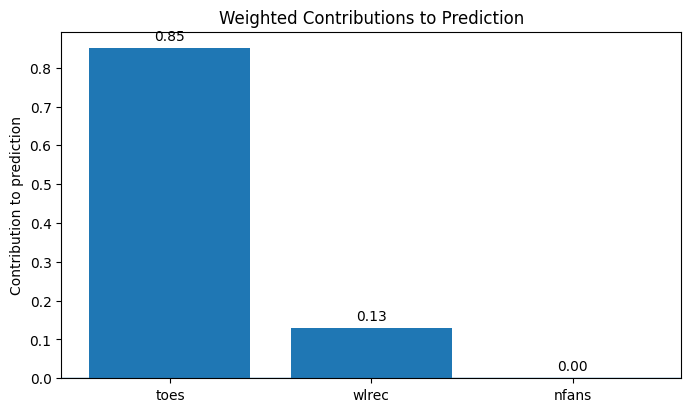

In [5]:
import matplotlib.pyplot as plt

inputs = [8.5, 0.65, 1.2]
weights = [0.1, 0.2, 0.0]
labels = ["toes", "wlrec", "nfans"]
contributions = [x*w for x, w in zip(inputs, weights)]

plt.figure(figsize=(8, 4.5))
bars = plt.bar(labels, contributions)
plt.ylabel("Contribution to prediction")
plt.title("Weighted Contributions to Prediction")
plt.axhline(0, linewidth=1)

for bar, value in zip(bars, contributions):
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.02,
             f"{value:.2f}", ha="center")

plt.show()

### Interpretasi

Pada contoh buku:

```text
toes  → 8.50 × 0.1 = 0.85
wlrec → 0.65 × 0.2 = 0.13
nfans → 1.20 × 0.0 = 0.00

Total = 0.98
```

Chart menunjukkan **kontribusi masing-masing input**, bukan sekadar nilai input mentah.

## 4. Vector & Dot Product

Ketika input dan weights menjadi kumpulan angka, kita menggunakan **vector**.

```text
input   = [8.5, 0.65, 1.2]
weights = [0.1, 0.2, 0.0]
```

Weighted sum tersebut juga merupakan **dot product**:

**input · weights = 0.98**

Secara intuitif, dot product menggabungkan pasangan nilai berdasarkan posisi lalu menjumlahkannya.

In [6]:
import numpy as np

weights = np.array([0.1, 0.2, 0])
input = np.array([8.5, 0.65, 1.2])

prediction = input.dot(weights)
print("Dot product:", prediction)

Dot product: 0.9800000000000001


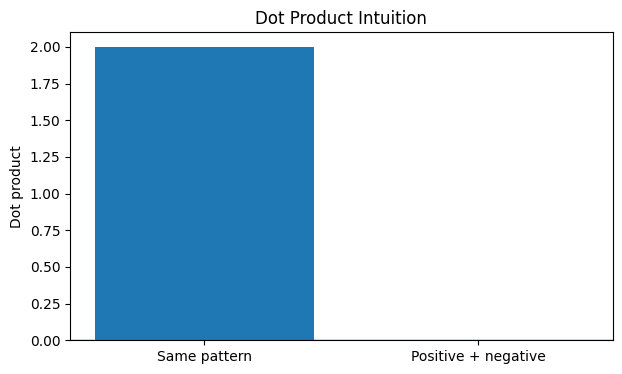

In [7]:
import matplotlib.pyplot as plt
import numpy as np

a = np.array([0, 1, 1, 0])
b = np.array([0, 1, 1, 0])
c = np.array([0, 1, -1, 0])

values = [a.dot(b), a.dot(c)]
labels = ["Same pattern", "Positive + negative"]

plt.figure(figsize=(7, 4))
plt.bar(labels, values)
plt.ylabel("Dot product")
plt.title("Dot Product Intuition")
plt.axhline(0, linewidth=1)
plt.show()

**Intuisi:** dot product dapat memberikan sinyal similarity. Nilai negatif pada weight dapat mengurangi atau membatalkan kontribusi positif dari input lain.

## 5. Multiple Outputs

Sekarang arah diperluas:

```text
                 ┌──► output 1
Input ───────────┼──► output 2
                 └──► output 3
```

Satu input dapat menghasilkan beberapa prediction.

Buku menggunakan `wlrec = 0.65` dengan tiga weights:

```text
[0.3, 0.2, 0.9]
```

Sehingga:

```text
0.65 × [0.3, 0.2, 0.9]
= [0.195, 0.130, 0.585]
```

In [8]:
def ele_mul(number, vector):
    output = [0, 0, 0]
    assert(len(output) == len(vector))
    for i in range(len(vector)):
        output[i] = number * vector[i]
    return output

weights = [0.3, 0.2, 0.9]

def neural_network(input, weights):
    return ele_mul(input, weights)

input = 0.65
pred = neural_network(input, weights)
print("Predictions:", pred)

Predictions: [0.195, 0.13, 0.5850000000000001]


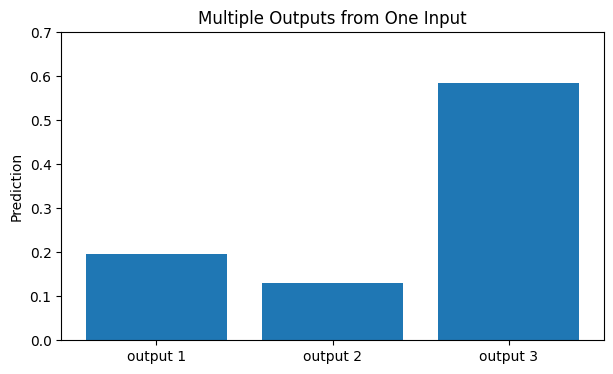

In [9]:
import matplotlib.pyplot as plt

pred = [0.195, 0.130, 0.585]
labels = ["output 1", "output 2", "output 3"]

plt.figure(figsize=(7, 4))
plt.bar(labels, pred)
plt.ylabel("Prediction")
plt.title("Multiple Outputs from One Input")
plt.ylim(0, 0.7)
plt.show()

## 6. Multiple Inputs + Multiple Outputs

Keduanya dapat digabungkan.

```text
                 ┌────────► output 1
input 1 ─────────┼────────► output 2
input 2 ─────────┼────────► output 3
input 3 ─────────┘
```

Sekarang weights direpresentasikan sebagai **matrix**.

Secara konseptual:

**Input Vector × Weight Matrix → Prediction Vector**

In [10]:
def vect_mat_mul(vect, matrix):
    assert(len(vect) == len(matrix))
    output = [0, 0, 0]
    for i in range(len(vect)):
        output[i] = w_sum(vect, matrix[i])
    return output

weights = [
    [0.1, 0.1, -0.3],
    [0.1, 0.2, 0.0],
    [0.0, 1.3, 0.1]
]

def neural_network(input, weights):
    return vect_mat_mul(input, weights)

input = [8.5, 0.65, 1.2]
pred = neural_network(input, weights)
print("Predictions:", pred)

Predictions: [0.555, 0.9800000000000001, 0.9650000000000001]


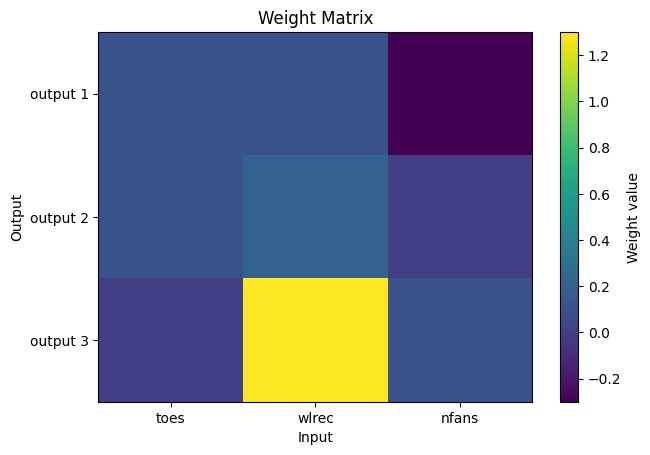

In [11]:
import numpy as np
import matplotlib.pyplot as plt

W = np.array([
    [0.1, 0.1, -0.3],
    [0.1, 0.2, 0.0],
    [0.0, 1.3, 0.1]
])

plt.figure(figsize=(7, 4.8))
plt.imshow(W, aspect="auto")
plt.xticks(range(3), ["toes", "wlrec", "nfans"])
plt.yticks(range(3), ["output 1", "output 2", "output 3"])
plt.xlabel("Input")
plt.ylabel("Output")
plt.title("Weight Matrix")
plt.colorbar(label="Weight value")
plt.show()

### Cara membaca heatmap

Setiap sel menunjukkan **weight** yang menghubungkan sebuah input dengan sebuah output.

- baris → output;
- kolom → input;
- angka → kekuatan dan arah hubungan.

Ini adalah bentuk visual yang lebih mudah dibaca daripada menuliskan seluruh matrix dalam paragraph.

## 7. Predicting on Predictions

Neural network dapat **stacked**.

```text
Input
  │
  ▼
┌──────────────┐
│  Network 1   │
└──────┬───────┘
       │ hidden prediction
       ▼
┌──────────────┐
│  Network 2   │
└──────┬───────┘
       ▼
 Final prediction
```

Output network pertama menjadi input network kedua. Buku menjelaskan bahwa stacking memungkinkan network menangani pola yang lebih kompleks daripada satu weight matrix saja.

In [12]:
ih_wgt = [
    [0.1, 0.2, -0.1],
    [-0.1, 0.1, 0.9],
    [0.1, 0.4, 0.1]
]

hp_wgt = [
    [0.3, 1.1, -0.3],
    [0.1, 0.2, 0.0],
    [0.0, 1.3, 0.1]
]

weights = [ih_wgt, hp_wgt]

def neural_network(input, weights):
    hid = vect_mat_mul(input, weights[0])
    pred = vect_mat_mul(hid, weights[1])
    return pred

input = [8.5, 0.65, 1.2]
pred = neural_network(input, weights)

print("Final prediction:", pred)

Final prediction: [0.21350000000000002, 0.14500000000000002, 0.5065]


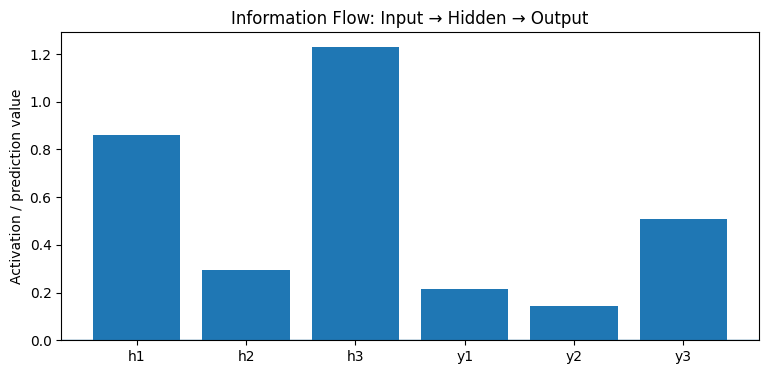

In [13]:
import numpy as np
import matplotlib.pyplot as plt

input_data = np.array([8.5, 0.65, 1.2])

hidden_weights = np.array([
    [0.1, 0.2, -0.1],
    [-0.1, 0.1, 0.9],
    [0.1, 0.4, 0.1]
])

output_weights = np.array([
    [0.3, 1.1, -0.3],
    [0.1, 0.2, 0.0],
    [0.0, 1.3, 0.1]
])

hidden = input_data @ hidden_weights.T
final = hidden @ output_weights.T

values = [*hidden, *final]
labels = ["h1", "h2", "h3", "y1", "y2", "y3"]

plt.figure(figsize=(9, 4))
plt.bar(labels, values)
plt.axhline(0, linewidth=1)
plt.ylabel("Activation / prediction value")
plt.title("Information Flow: Input → Hidden → Output")
plt.show()

## 8. NumPy Version

Chapter kemudian memperkenalkan NumPy sebagai cara yang lebih ringkas untuk melakukan operasi vector.

Untuk weighted sum:

```python
prediction = input.dot(weights)
```

Daripada menulis loop manual, NumPy menyediakan operasi **dot product** secara langsung.

In [14]:
import numpy as np

weights = np.array([0.1, 0.2, 0])
toes = np.array([8.5, 9.5, 9.9, 9.0])
wlrec = np.array([0.65, 0.8, 0.8, 0.9])
nfans = np.array([1.2, 1.3, 0.5, 1.0])

input = np.array([toes[0], wlrec[0], nfans[0]])
pred = input.dot(weights)

print("NumPy prediction:", pred)

NumPy prediction: 0.9800000000000001


## 9. Visual Summary

```text
             CHAPTER 3
                 │
                 ▼
              PREDICT
                 │
       ┌─────────┴─────────┐
       ▼                   ▼
  Single Input        Multiple Inputs
       │                   │
 input × weight        Weighted Sum
                           │
                       Dot Product
                           │
                 ┌─────────┴─────────┐
                 ▼                   ▼
        Multiple Outputs     Input + Output
                 │                   │
           Elementwise        Matrix / Vector
           Multiplication      Multiplication
                 └─────────┬─────────┘
                           ▼
                  Predicting on
                    Predictions
                           │
                           ▼
                  Stacked Networks
```

## Concept Check

| Question | Jawaban singkat |
|---|---|
| Apa fungsi weight? | Mengatur seberapa kuat input memengaruhi prediction |
| Single input + single output? | `input × weight` |
| Multiple inputs? | Weighted sum / dot product |
| Multiple outputs? | Elementwise multiplication |
| List of vectors? | Matrix |
| Vector + matrix? | Vector-matrix multiplication |
| Output network 1 → input network 2? | Predicting on predictions |
| Fokus Chapter 3? | **PREDICT / forward propagation** |

## Key Takeaways

### 🧠 Core idea
**Neural Network = Information (Input) + Knowledge (Weights) → Prediction**

### 🔢 Core operation
**Weighted Sum / Dot Product**

### 📐 Core structure
**Vector → Matrix → Prediction Vector**

### 🧱 Core architecture
**Network 1 → Network 2 → ...**

### 🎯 Fokus chapter
**Forward Propagation / Prediction**

Chapter berikutnya baru masuk ke bagian **COMPARE** dan **LEARN**, yaitu bagaimana network mengetahui bahwa prediction-nya salah dan bagaimana weight diperbarui.

## Chapter Summary

Chapter 3 mengubah konsep pada Chapter 2 menjadi proses komputasi nyata.

Kita mulai dari:

**`prediction = input × weight`**

lalu berkembang menjadi:

**Multiple Inputs → Weighted Sum → Prediction**

dan:

**Multiple Inputs + Multiple Outputs → Vector-Matrix Multiplication**

Terakhir, output sebuah network dapat digunakan sebagai input network berikutnya melalui **predicting on predictions**.

> **Input → Weights → Forward Propagation → Prediction**

## Reference

Trask, A. W. (2019). *Grokking Deep Learning*. Manning Publications.

**Source:** Chapter 3 — *Introduction to Neural Prediction: Forward Propagation*